# Credit Card Fraud Detection

**Dataset:** [Kaggle Credit Card Fraud Dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) - 284,807 transactions from European cardholders (Sept 2013), with only 492 fraud cases (~0.17%).

The main challenge here is that this is a heavily imbalanced classification problem. A model that just predicts "not fraud" every time would get 99.83% accuracy, which is obviously useless. So the focus needs to be on precision-recall rather than just accuracy.

Features V1-V28 are PCA-transformed (anonymized). Only `Time`, `Amount`, and `Class` are in their original form.

## Imports

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_curve, average_precision_score,
                             roc_curve, roc_auc_score, f1_score,
                             precision_score, recall_score, accuracy_score)
from imblearn.over_sampling import SMOTE

# gets rid of annoying warnings cluttering the output
import warnings
warnings.filterwarnings('ignore')

# make plots look nicer
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# folder for saving plots
os.makedirs('obtained_fig', exist_ok=True)

## Loading the Data

V1-V28 are PCA components (anonymized), `Time` is seconds since first transaction, `Amount` is the transaction value, and `Class` is the target (0 = legit, 1 = fraud).

In [22]:
df = pd.read_csv('creditcard.csv')
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [23]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [24]:
# column names
df.columns.tolist()

['Time',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'Amount',
 'Class']

In [25]:
# data types + memory
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [26]:
# any nulls?
df.isnull().sum().sum()

np.int64(0)

## Basic Stats & Class Distribution

Descriptive stats and checking how bad the class imbalance is.

In [27]:
df[['Time', 'Amount', 'Class']].describe()

,Time,Amount,Class
count,284807.000000,284807.000000,284807.000000
mean,94813.859575,88.349619,0.001727
std,47488.145955,250.120109,0.041527
min,0.000000,0.000000,0.000000
25%,54201.500000,5.600000,0.000000
50%,84692.000000,22.000000,0.000000
75%,139320.500000,77.165000,0.000000
max,172792.000000,25691.160000,1.000000


In [28]:
# transposed so its easier to read
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


The fraud ratio is basically fraud_count / total * 100. If it's super low (which it is), then accuracy is a bad metric since a "predict all legit" model would score 99.8%+.

In [29]:
# class distribution
print(df['Class'].value_counts())
print()
print(df['Class'].value_counts(normalize=True) * 100)

# how bad is it
fraud_count = df['Class'].sum()
total = len(df)
print(f"\nFraud ratio: {fraud_count}/{total} = {fraud_count/total*100:.4f}%")
print(f"Roughly 1 fraud per {(total - fraud_count) // fraud_count} legit transactions")

Class
0    284315
1       492
Name: count, dtype: int64

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

Fraud ratio: 492/284807 = 0.1727%
Roughly 1 fraud per 577 legit transactions


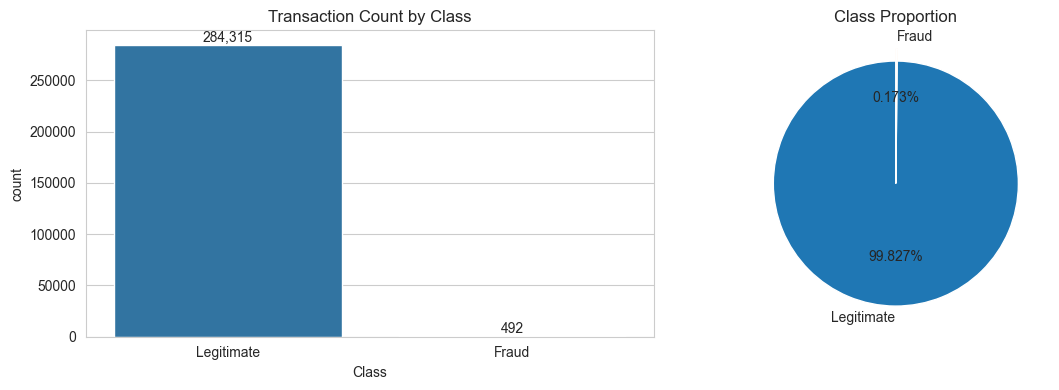

In [30]:
# visualize the imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# bar chart
sns.countplot(x='Class', data=df, ax=axes[0])
axes[0].set_title('Transaction Count by Class')
axes[0].set_xticklabels(['Legitimate', 'Fraud'])

# put count labels on bars
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom')

# pie chart
axes[1].pie(df['Class'].value_counts(), labels=['Legitimate', 'Fraud'],
            autopct='%1.3f%%', startangle=90, explode=[0, 0.1])
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.savefig('obtained_fig/class_distribution.png', bbox_inches='tight')
plt.show()

## Preprocessing - Scaling

V1-V28 are already standardized from PCA, but `Amount` and `Time` are on totally different scales. Need to fix that because it messes with distance-based methods (like SMOTE) and gradient-based models.

StandardScaler just does `z = (x - mean) / std` for each feature.

In [31]:
scaler = StandardScaler()

# scale amount and time to match PCA features
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

# drop originals since we have scaled versions now
df.drop(['Amount', 'Time'], axis=1, inplace=True)
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Amount_scaled,Time_scaled
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,-1.996562
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534,-1.996562
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403,-1.996541


In [32]:
# duplicates?
dupes = df.duplicated().sum()
print(f"Duplicates: {dupes}")

if dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f"After dropping: {len(df)} rows")

Duplicates: 1081
After dropping: 283726 rows


In [33]:
print(df.shape)
df.head()

(283726, 31)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Amount_scaled,Time_scaled
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,-1.996562
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534,-1.996562
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403,-1.996541


## EDA

Comparing fraud vs legit transactions - amount, time, and which PCA features separate them.

In [34]:
# separate fraud and legit for plots
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]
print(f"Legit: {len(legit)}, Fraud: {len(fraud)}")

Legit: 283253, Fraud: 473


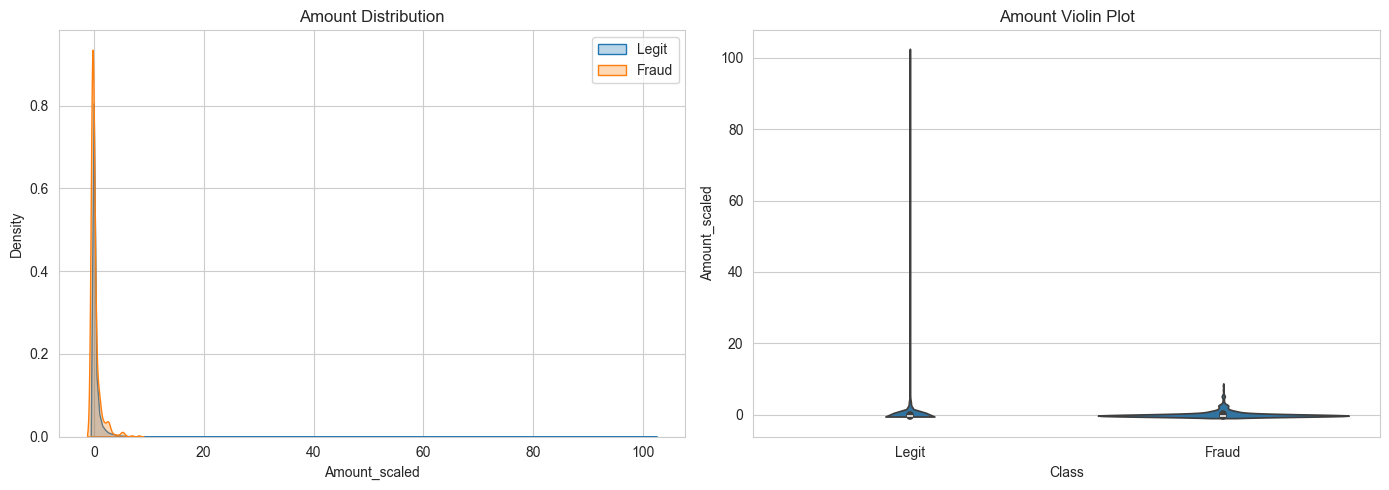

In [35]:
# amount distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(legit['Amount_scaled'], label='Legit', fill=True, alpha=0.3, ax=axes[0])
sns.kdeplot(fraud['Amount_scaled'], label='Fraud', fill=True, alpha=0.3, ax=axes[0])
axes[0].set_title('Amount Distribution')
axes[0].legend()

# violin plot
violin_data = df[['Amount_scaled', 'Class']].copy()
violin_data['Class'] = violin_data['Class'].map({0: 'Legit', 1: 'Fraud'})
sns.violinplot(x='Class', y='Amount_scaled', data=violin_data, ax=axes[1])
axes[1].set_title('Amount Violin Plot')

plt.tight_layout()
plt.savefig('obtained_fig/amount_distribution.png', bbox_inches='tight')
plt.show()

Checking if fraud transactions happen at specific times:

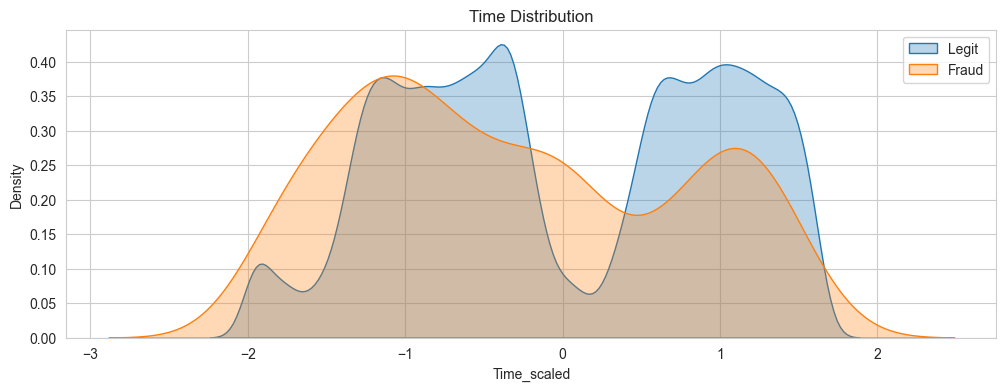

In [36]:
# time distribution - do frauds happen at certain times?
plt.figure(figsize=(12, 4))
sns.kdeplot(legit['Time_scaled'], label='Legit', fill=True, alpha=0.3)
sns.kdeplot(fraud['Time_scaled'], label='Fraud', fill=True, alpha=0.3)
plt.title('Time Distribution')
plt.legend()
plt.savefig('obtained_fig/time_distribution.png', bbox_inches='tight')
plt.show()

Looking at some PCA features - picked ones that seemed to have different distributions for fraud vs legit:

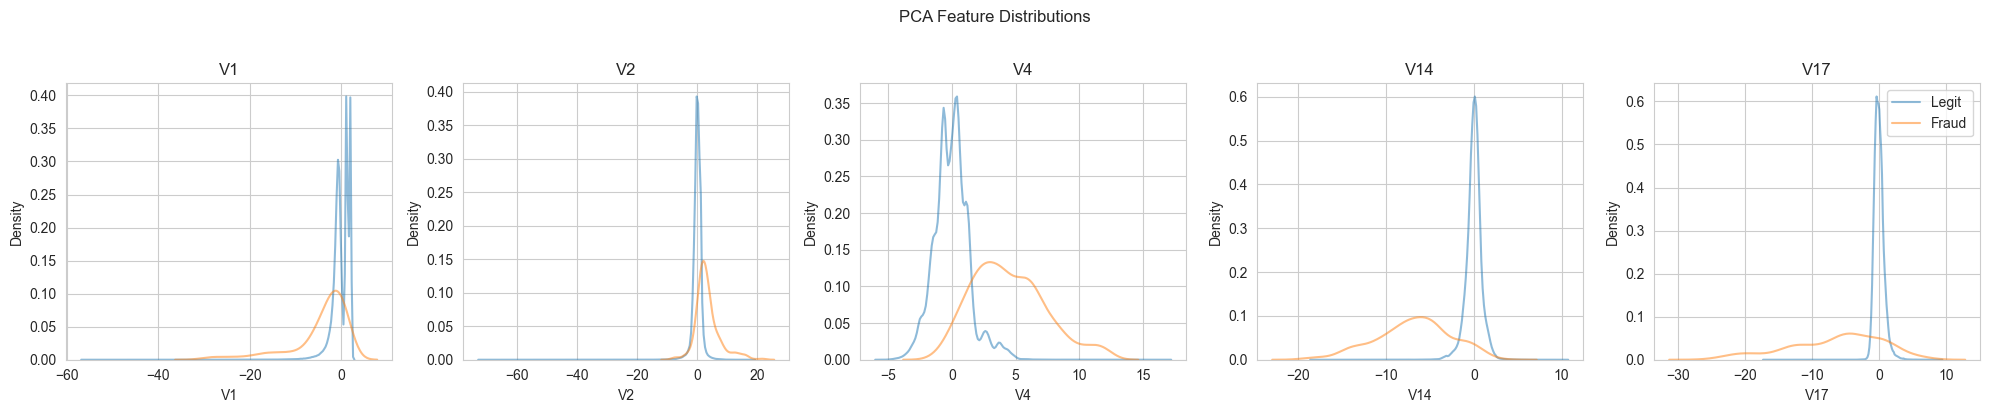

In [37]:
# some PCA features that seem to separate the classes well
features_to_check = ['V1', 'V2', 'V4', 'V14', 'V17']

fig, axes = plt.subplots(1, len(features_to_check), figsize=(20, 4))
for i, feat in enumerate(features_to_check):
    sns.kdeplot(legit[feat], label='Legit', alpha=0.5, ax=axes[i])
    sns.kdeplot(fraud[feat], label='Fraud', alpha=0.5, ax=axes[i])
    axes[i].set_title(feat)
    if i == len(features_to_check) - 1:
        axes[i].legend()

plt.suptitle('PCA Feature Distributions', y=1.02)
plt.tight_layout()
plt.savefig('obtained_fig/pca_distributions.png', bbox_inches='tight')
plt.show()

## Correlation Analysis

Since the V features are PCA components they're already uncorrelated with each other, so the main thing to look at is how each feature correlates with the target (`Class`).

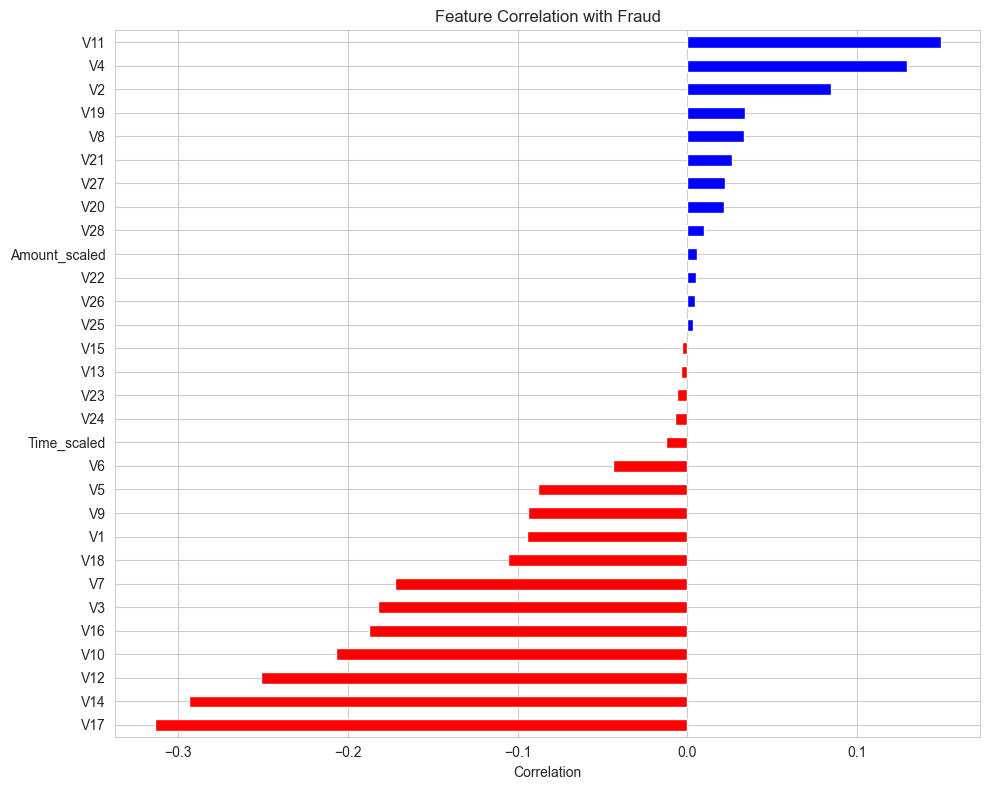

Top positive:
V8     0.033068
V19    0.033631
V2     0.084624
V4     0.129326
V11    0.149067
Name: Class, dtype: float64

Top negative:
V17   -0.313498
V14   -0.293375
V12   -0.250711
V10   -0.206971
V16   -0.187186
Name: Class, dtype: float64


In [38]:
# how much each feature correlates with fraud
corr_with_class = df.corr()['Class'].drop('Class').sort_values()

plt.figure(figsize=(10, 8))
colors = ['red' if x < 0 else 'blue' for x in corr_with_class]
corr_with_class.plot(kind='barh', color=colors)
plt.title('Feature Correlation with Fraud')
plt.xlabel('Correlation')
plt.tight_layout()
plt.savefig('obtained_fig/correlation_bar.png', bbox_inches='tight')
plt.show()

# top correlated features
print("Top positive:")
print(corr_with_class.tail(5))
print("\nTop negative:")
print(corr_with_class.head(5))

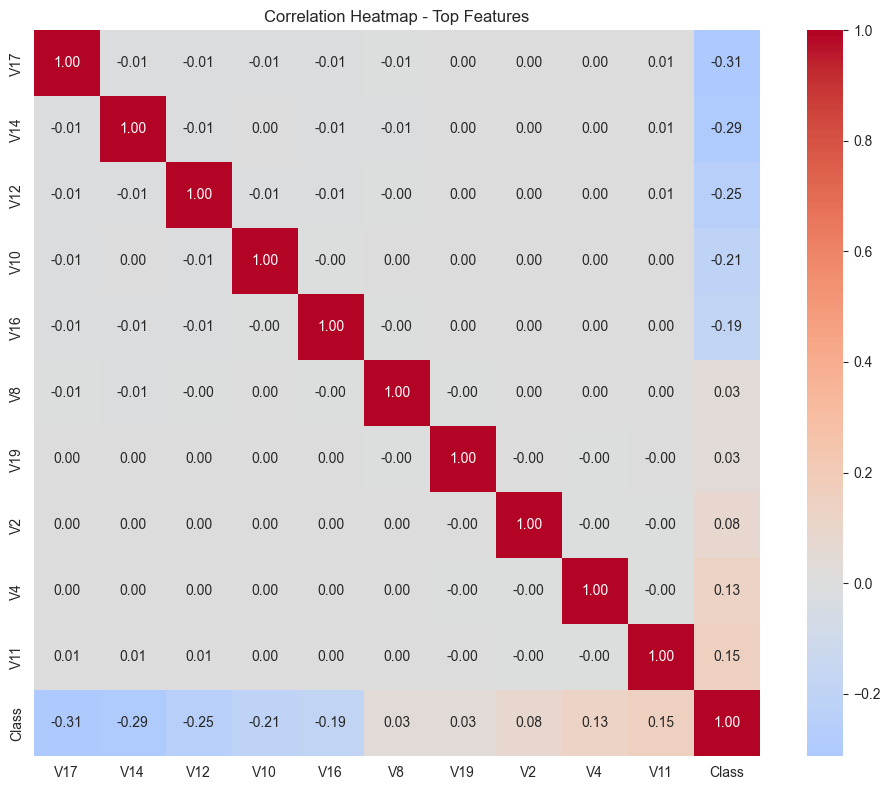

In [39]:
# heatmap of top features
top_feats = list(corr_with_class.head(5).index) + list(corr_with_class.tail(5).index) + ['Class']

plt.figure(figsize=(10, 8))
sns.heatmap(df[top_feats].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True)
plt.title('Correlation Heatmap - Top Features')
plt.tight_layout()
plt.savefig('obtained_fig/correlation_heatmap.png', bbox_inches='tight')
plt.show()

## Train-Test Split

Important: splitting **before** SMOTE. Oversampling first then splitting means synthetic samples could leak into the test set and give inflated results.

In [40]:
X = df.drop('Class', axis=1)
y = df['Class']

# stratify keeps the same fraud % in train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Train fraud: {y_train.sum()} ({y_train.mean()*100:.3f}%)")
print(f"Test fraud:  {y_test.sum()} ({y_test.mean()*100:.3f}%)")

Train: 226980, Test: 56746
Train fraud: 378 (0.167%)
Test fraud:  95 (0.167%)


## Handling Imbalance with SMOTE

SMOTE generates synthetic minority samples by interpolating between existing fraud cases and their nearest neighbors:

$$x_{new} = x_i + \lambda \cdot (x_{nn} - x_i), \quad \lambda \in [0, 1]$$

This is better than just duplicating fraud rows because it creates new realistic-ish samples. Only applying this to training data obviously.

In [41]:
# SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Before: {y_train.value_counts().to_dict()}")
print(f"After:  {pd.Series(y_train_smote).value_counts().to_dict()}")
print(f"Total went from {len(y_train)} to {len(y_train_smote)}")

Before: {0: 226602, 1: 378}
After:  {0: 226602, 1: 226602}
Total went from 226980 to 453204


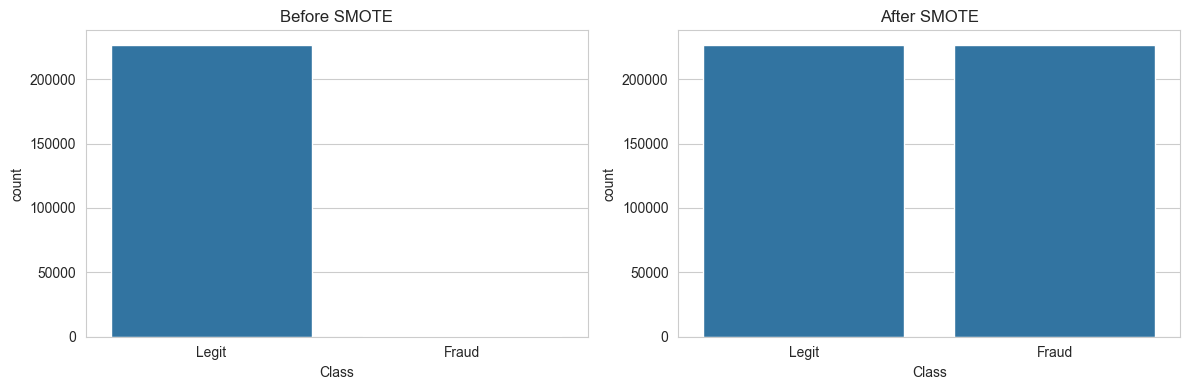

In [42]:
# before vs after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title('Before SMOTE')
axes[0].set_xticklabels(['Legit', 'Fraud'])

sns.countplot(x=y_train_smote, ax=axes[1])
axes[1].set_title('After SMOTE')
axes[1].set_xticklabels(['Legit', 'Fraud'])

plt.tight_layout()
plt.savefig('obtained_fig/smote_comparison.png', bbox_inches='tight')
plt.show()

## Model Training

Training 3 models to compare:
- **Logistic Regression** - simple baseline, easy to interpret
- **Random Forest** - ensemble of decision trees, handles non-linear patterns
- **XGBoost** - gradient boosting, usually does well on tabular data

### Logistic Regression

In [43]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_smote, y_train_smote)

lr_pred = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]  # prob of being fraud

print(f"Acc: {accuracy_score(y_test, lr_pred):.4f}")
print(f"Recall: {recall_score(y_test, lr_pred):.4f}")
print(f"F1: {f1_score(y_test, lr_pred):.4f}")

Acc: 0.9737
Recall: 0.8737
F1: 0.1002


### Random Forest

Also setting `class_weight='balanced'` which gives more weight to the minority class during training.

In [44]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10,
                                  class_weight='balanced',  # helps with imbalance
                                  random_state=42, n_jobs=-1)
rf_model.fit(X_train_smote, y_train_smote)

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print(f"Acc: {accuracy_score(y_test, rf_pred):.4f}")
print(f"Recall: {recall_score(y_test, rf_pred):.4f}")
print(f"F1: {f1_score(y_test, rf_pred):.4f}")

Acc: 0.9986
Recall: 0.8000
F1: 0.6496


### XGBoost

XGBoost has a `scale_pos_weight` param that can handle imbalance, but since SMOTE is already applied it's set to 1 here. Calculating the ratio anyway just to see it.

In [45]:
# imbalance ratio (not using it since we have SMOTE but good to know)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Imbalance ratio: {scale_pos_weight:.1f}")

xgb_model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.8,
                           scale_pos_weight=1,  # already using SMOTE so set to 1
                           eval_metric='logloss',
                           random_state=42, n_jobs=-1)
xgb_model.fit(X_train_smote, y_train_smote)

xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

print(f"\nAcc: {accuracy_score(y_test, xgb_pred):.4f}")
print(f"Recall: {recall_score(y_test, xgb_pred):.4f}")
print(f"F1: {f1_score(y_test, xgb_pred):.4f}")

Imbalance ratio: 599.5

Acc: 0.9980
Recall: 0.8211
F1: 0.5735


## Evaluation

### Precision-Recall Curves

For imbalanced problems, PR curves are way more informative than ROC. The AUPRC (area under PR curve) is really the main metric to look at here.

- **Precision** = TP / (TP + FP) - of the ones flagged, how many are actually fraud?
- **Recall** = TP / (TP + FN) - of all actual frauds, how many got caught?

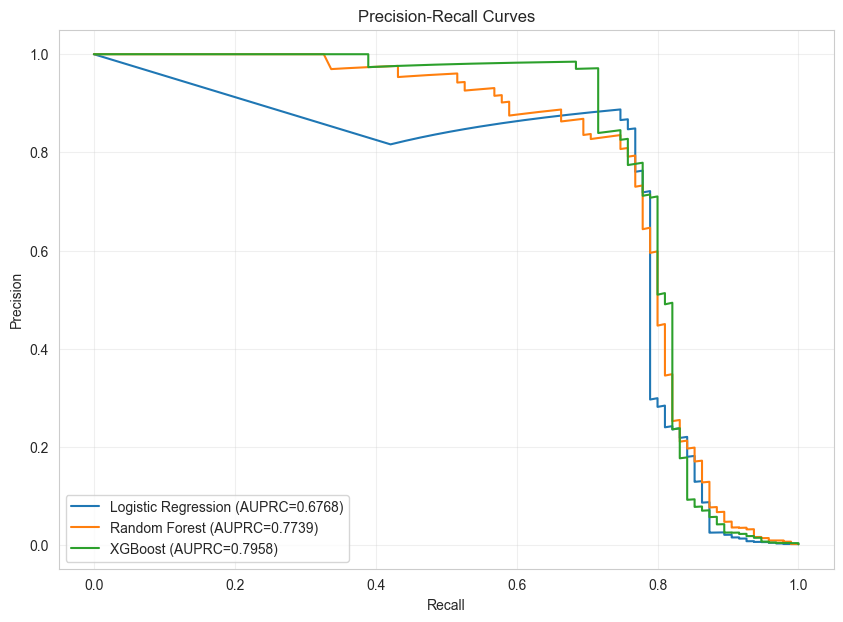

Logistic Regression: AUPRC = 0.6768
Random Forest: AUPRC = 0.7739
XGBoost: AUPRC = 0.7958


In [46]:
models = {
    'Logistic Regression': lr_proba,
    'Random Forest': rf_proba,
    'XGBoost': xgb_proba
}

plt.figure(figsize=(10, 7))
for name, proba in models.items():
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    plt.plot(rec, prec, label=f'{name} (AUPRC={ap:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('obtained_fig/pr_curves.png', bbox_inches='tight')
plt.show()

for name, proba in models.items():
    print(f"{name}: AUPRC = {average_precision_score(y_test, proba):.4f}")

### Confusion Matrices

F1 = 2 * (precision * recall) / (precision + recall) - balances both metrics.

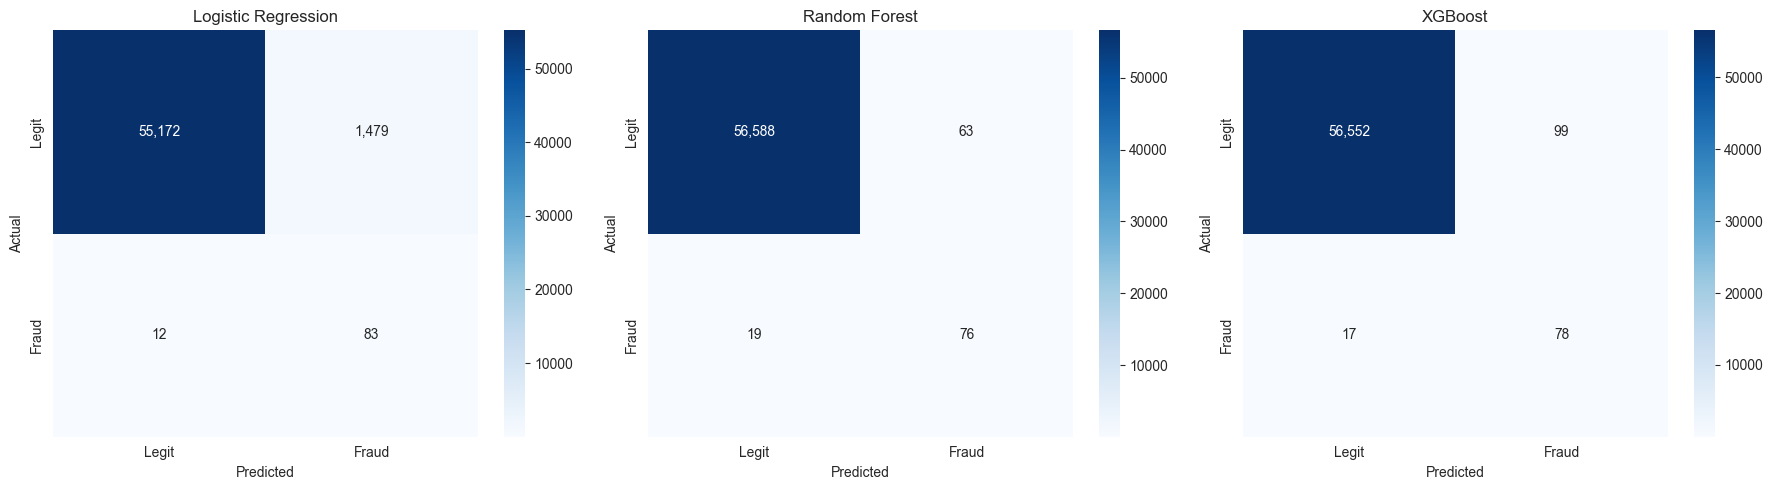

In [47]:
model_preds = {
    'Logistic Regression': lr_pred,
    'Random Forest': rf_pred,
    'XGBoost': xgb_pred
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, pred) in zip(axes, model_preds.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
    ax.set_title(name)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('obtained_fig/confusion_matrices.png', bbox_inches='tight')
plt.show()

# read it as: rows = what it actually is, columns = what the model predicted

In [48]:
# classification reports + breakdown
for name, pred in model_preds.items():
    print(f"\n--- {name} ---")
    print(classification_report(y_test, pred, target_names=['Legit', 'Fraud']))
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()  # unpack the 4 values
    print(f"  TP: {tp}, FN: {fn}, FP: {fp}, TN: {tn}")


--- Logistic Regression ---
              precision    recall  f1-score   support

       Legit       1.00      0.97      0.99     56651
       Fraud       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746

  TP: 83, FN: 12, FP: 1479, TN: 55172

--- Random Forest ---
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56651
       Fraud       0.55      0.80      0.65        95

    accuracy                           1.00     56746
   macro avg       0.77      0.90      0.82     56746
weighted avg       1.00      1.00      1.00     56746

  TP: 76, FN: 19, FP: 63, TN: 56588

--- XGBoost ---
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56651
       Fraud       0.44      0.82      0.57        95

    accuracy                           

### ROC Curves

Including these for completeness but ROC can be misleading here - with so many true negatives, even lots of false positives barely move the FPR needle.

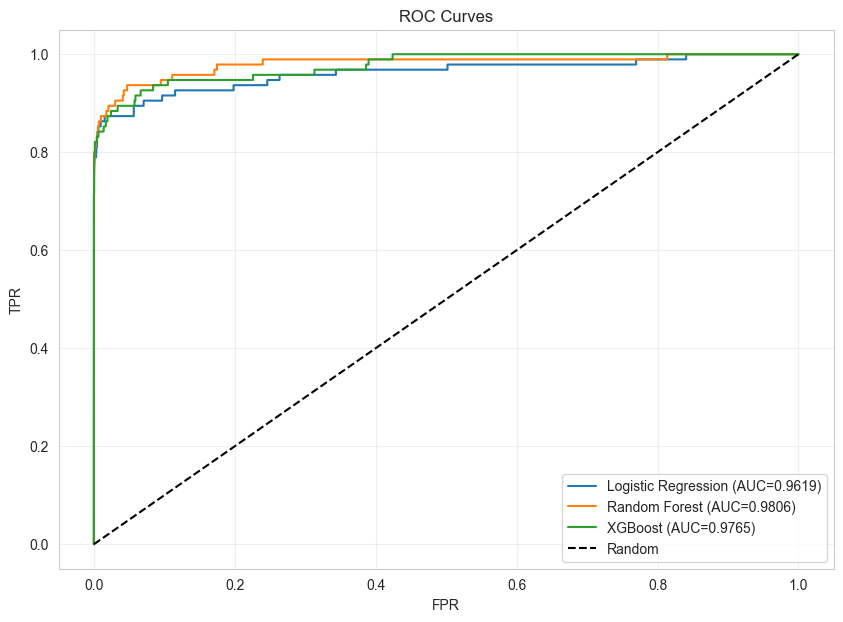

Logistic Regression: AUC = 0.9619
Random Forest: AUC = 0.9806
XGBoost: AUC = 0.9765


In [49]:
plt.figure(figsize=(10, 7))
for name, proba in models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_score = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')  # diagonal = random guessing baseline
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curves')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('obtained_fig/roc_curves.png', bbox_inches='tight')
plt.show()

for name, proba in models.items():
    print(f"{name}: AUC = {roc_auc_score(y_test, proba):.4f}")

## Threshold Tuning

Default is 0.5 but finding a better threshold that maximizes F1 for the best model.

In [50]:
# pick best model by AUPRC
best_name = max(models, key=lambda m: average_precision_score(y_test, models[m]))
best_proba = models[best_name]
print(f"Best: {best_name}")

# try different thresholds to find the one that gives best F1
prec_vals, rec_vals, thresholds = precision_recall_curve(y_test, best_proba)
f1_vals = 2 * (prec_vals[:-1] * rec_vals[:-1]) / (prec_vals[:-1] + rec_vals[:-1] + 1e-8)  # +1e-8 to avoid dividing by 0
best_thresh = thresholds[np.argmax(f1_vals)]
print(f"Best threshold: {best_thresh:.4f} (F1={f1_vals.max():.4f})")

# apply it instead of default 0.5
y_tuned = (best_proba >= best_thresh).astype(int)
print(f"\nWith tuned threshold:")
print(classification_report(y_test, y_tuned, target_names=['Legit', 'Fraud']))

Best: XGBoost
Best threshold: 0.9829 (F1=0.8242)

With tuned threshold:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56651
       Fraud       0.97      0.72      0.82        95

    accuracy                           1.00     56746
   macro avg       0.99      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746



## Feature Importance

Which features are actually driving the predictions? This helps verify the model is learning real patterns and not just noise.

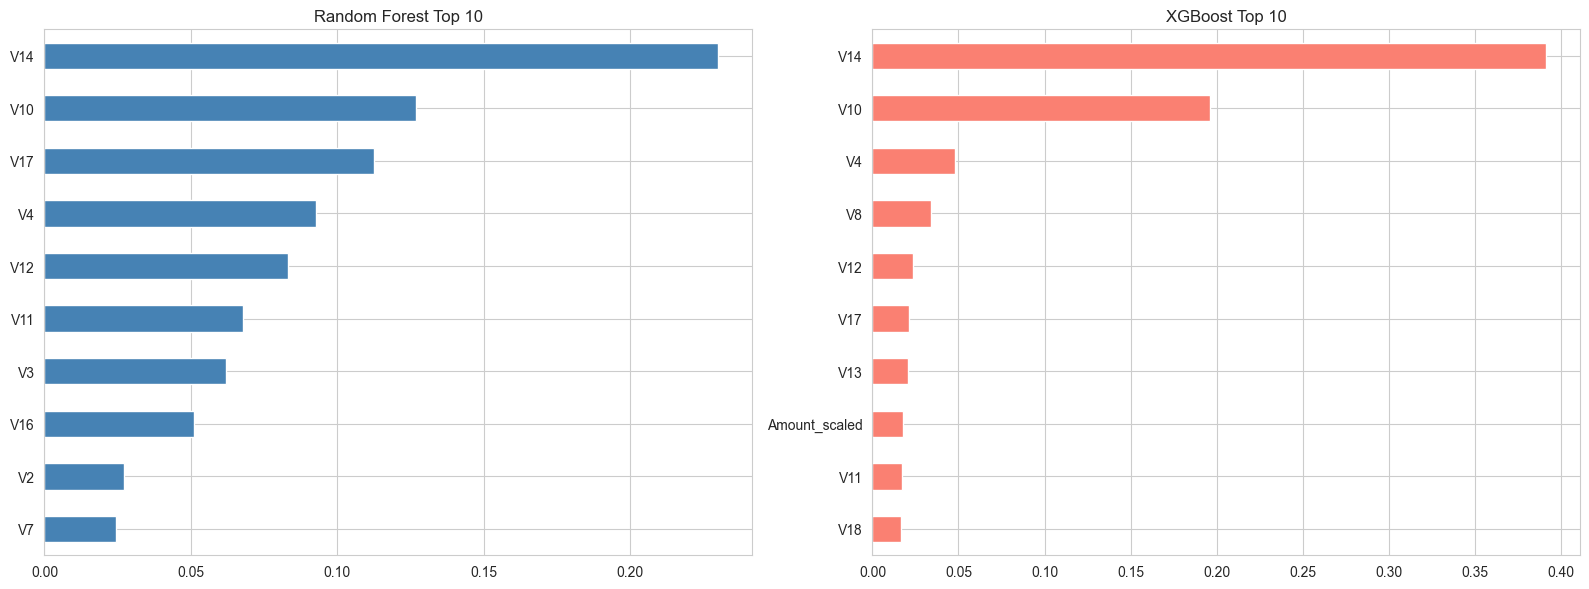

In [51]:
# feature importance - which features matter most to each model
rf_imp = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
xgb_imp = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rf_imp.head(10).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Random Forest Top 10')
axes[0].invert_yaxis()  # so highest is on top

xgb_imp.head(10).plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title('XGBoost Top 10')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('obtained_fig/feature_importance.png', bbox_inches='tight')
plt.show()

## Cross-Validation

Running 5-fold stratified CV to make sure the results aren't just lucky based on one particular split.

In [52]:
# quick 5-fold CV on best model to check if results hold
if best_name == 'XGBoost':
    cv_model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                              scale_pos_weight=scale_pos_weight,
                              eval_metric='logloss', random_state=42, n_jobs=-1)
elif best_name == 'Random Forest':
    cv_model = RandomForestClassifier(n_estimators=100, max_depth=10,
                                      class_weight='balanced', random_state=42, n_jobs=-1)
else:
    cv_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_validate(cv_model, X, y, cv=cv, scoring='f1', n_jobs=-1)
print(f"5-Fold CV F1 ({best_name}): {cv_scores['test_score'].mean():.4f} +/- {cv_scores['test_score'].std():.4f}")

5-Fold CV F1 (XGBoost): 0.7976 +/- 0.0171


## Ethical Considerations

A few things worth noting about deploying something like this:

**False positives vs false negatives** - blocking a legitimate transaction is annoying for the customer, but missing a fraud means real financial loss. There's always a tradeoff and the decision depends on the context.

**Dataset limitations** - this is only 2 days of European transactions from 2013. Fraud patterns change over time and vary by region, so a model trained on this wouldn't necessarily work well in other settings. Also, only fraud that was *caught* gets labeled - if some fraud slipped through undetected, it's mislabeled as legitimate in the data.

**Privacy** - the PCA anonymization is good, but in practice any fraud detection system needs to comply with regulations like GDPR. Can't really check for demographic bias here either since the features are anonymized.

## Results Summary

In [53]:
# summary table
results = []
for name, pred, proba in [('Logistic Regression', lr_pred, lr_proba),
                           ('Random Forest', rf_pred, rf_proba),
                           ('XGBoost', xgb_pred, xgb_proba)]:
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'AUPRC': average_precision_score(y_test, proba),
        'ROC-AUC': roc_auc_score(y_test, proba),
        'TP': tp, 'FN': fn, 'FP': fp
    })

results_df = pd.DataFrame(results).set_index('Model')
results_df

,Accuracy,Precision,Recall,F1,AUPRC,ROC-AUC,TP,FN,FP
Model,,,,,,,,,
Logistic Regression,0.973725,0.053137,0.873684,0.100181,0.676813,0.961885,83,12,1479
Random Forest,0.998555,0.546763,0.800000,0.649573,0.773863,0.980554,76,19,63
XGBoost,0.997956,0.440678,0.821053,0.573529,0.795812,0.976457,78,17,99


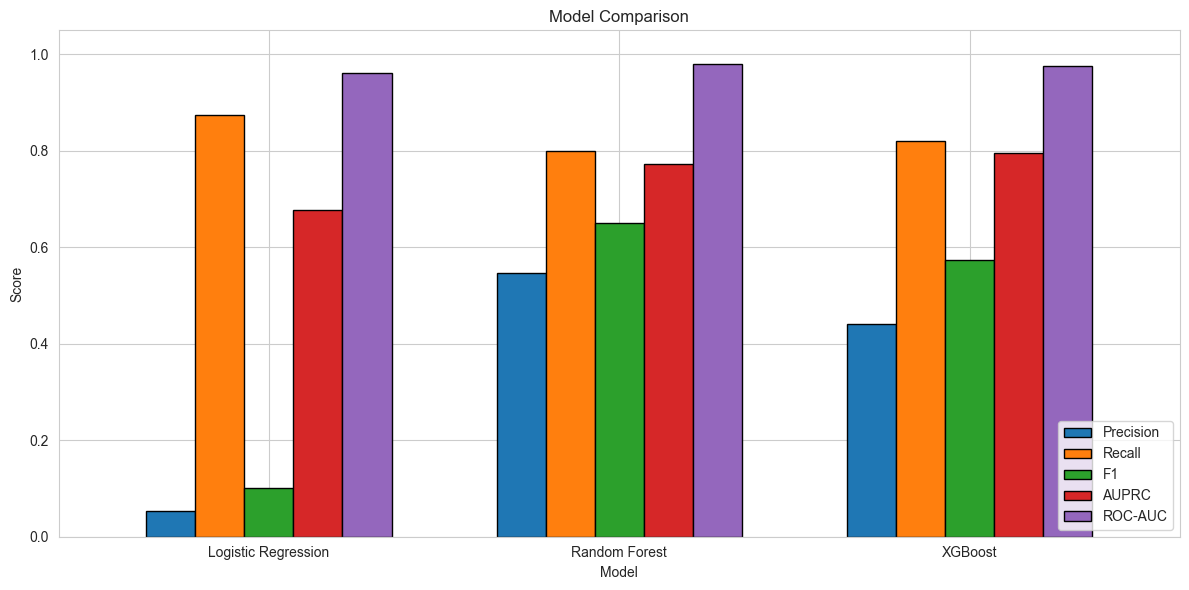

In [54]:
metrics_to_plot = ['Precision', 'Recall', 'F1', 'AUPRC', 'ROC-AUC']
results_df[metrics_to_plot].plot(kind='bar', figsize=(12, 6), edgecolor='black', width=0.7)
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('obtained_fig/model_comparison.png', bbox_inches='tight')
plt.show()

## Takeaways

- The extreme class imbalance (0.17% fraud) means accuracy is useless as a metric - AUPRC is much better for this kind of problem
- SMOTE helped balance the training data. Key thing was applying it *after* the train-test split to avoid data leakage
- All three models got high ROC-AUC but the PR curves showed more meaningful differences
- Threshold tuning gives control over the precision/recall tradeoff depending on what matters more in practice
- For a real system, retraining regularly is important since fraud patterns evolve, and having humans review flagged transactions helps too